In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

In [2]:
NS_MAX = 3
EW_MAX = 5
actions = [0, 1]  # 0 = EW green, 1 = NS green

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

In [3]:
def step(state, action):
    ns, ew = state

    # random arrivals
    ns += random.randint(0, 2)
    ew += random.randint(0, 2)

    # apply action
    if action == 0:
        ew = max(0, ew - random.randint(1, 2))
    else:
        ns = max(0, ns - random.randint(1, 2))

    # limits
    ns = min(ns, NS_MAX)
    ew = min(ew, EW_MAX)

    # reward
    reward = -(ns + ew)

    return (ns, ew), reward

In [4]:
Q = np.zeros((NS_MAX+1, EW_MAX+1, 2))

In [5]:
episodes = 1000

for ep in range(episodes):
    state = (random.randint(0, NS_MAX), random.randint(0, EW_MAX))

    for _ in range(50):

        # epsilon greedy
        if random.uniform(0,1) < epsilon:
            action = random.choice(actions)
        else:
            action = np.argmax(Q[state[0], state[1]])

        next_state, reward = step(state, action)

        # Q update
        Q[state[0], state[1], action] += alpha * (
            reward + gamma * np.max(Q[next_state[0], next_state[1]])
            - Q[state[0], state[1], action]
        )

        state = next_state

    # decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

In [6]:
def predict(ns, ew):
    ns = int(ns)
    ew = int(ew)

    action = np.argmax(Q[ns, ew])

    if action == 0:
        return f"Green Signal → East-West (NS={ns}, EW={ew})"
    else:
        return f"Green Signal → North-South (NS={ns}, EW={ew})"

🚦 SMART TRAFFIC CONTROL - DECISION PREDICTOR
Input traffic levels to see AI decision:

Example 1: Light traffic on both lanes


/var/folders/y1/m3_d2_456q10qt083w6f22h00000gn/T/ipykernel_87688/2448964237.py:76: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alokekissac/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


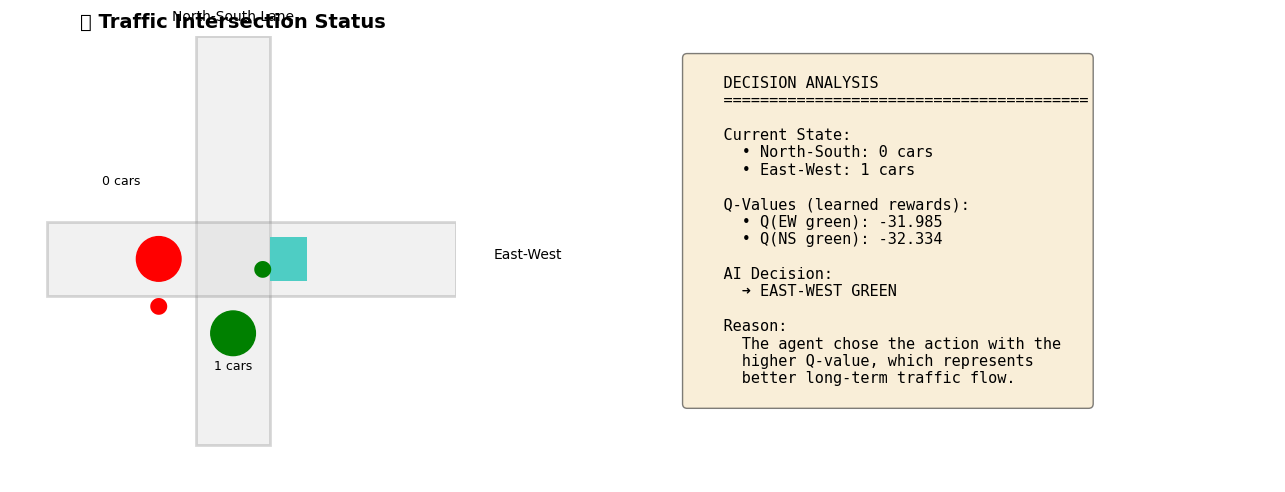



Example 2: Heavy NS, light EW


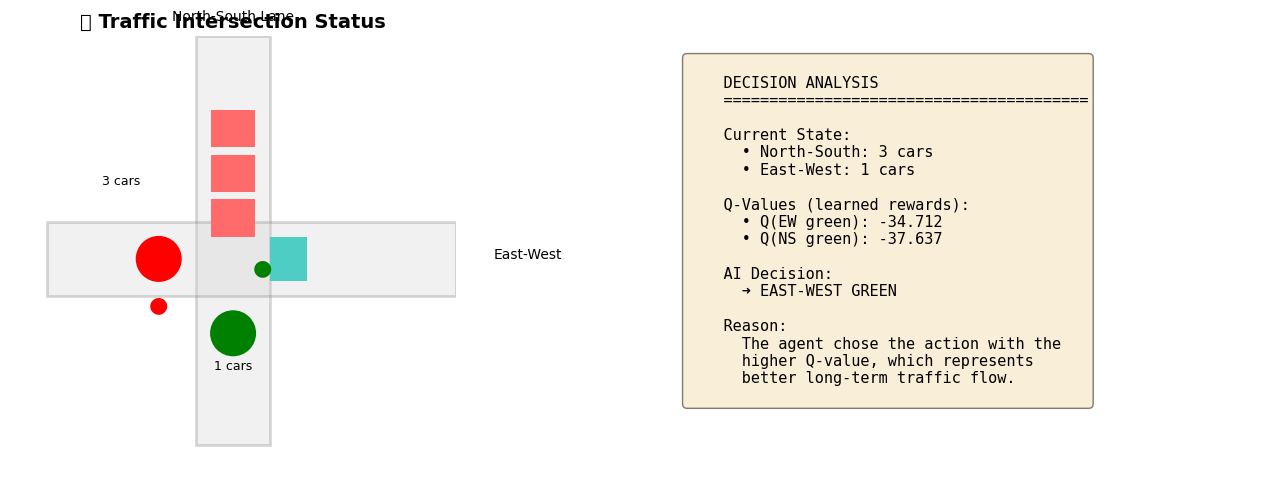



Example 3: Heavy EW, light NS


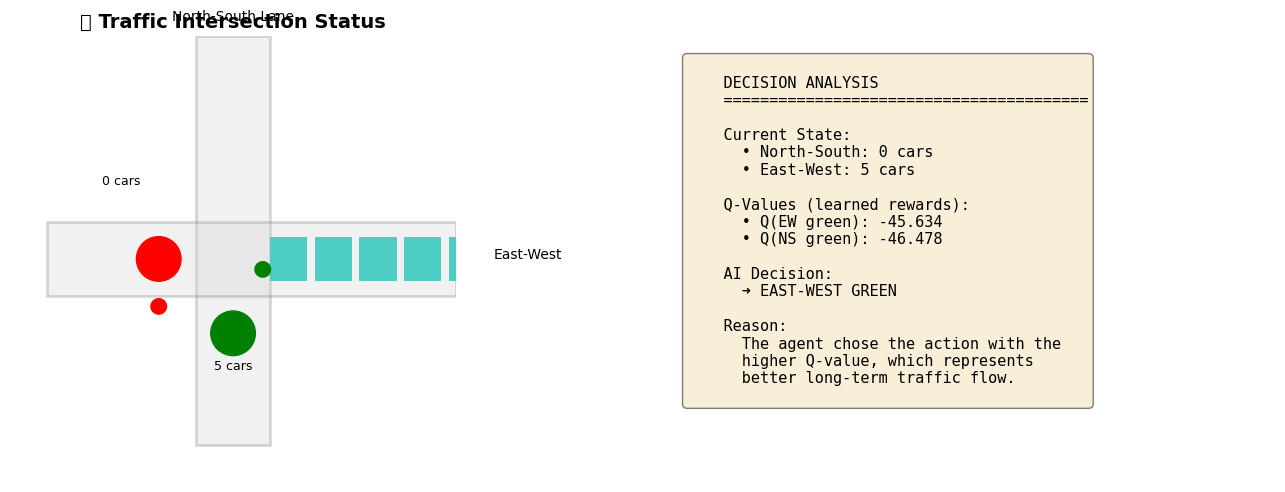

0

In [7]:
def visualize_decision(ns, ew):
    """Visualize traffic decision and Q-values"""
    ns = int(ns)
    ew = int(ew)
    
    action = np.argmax(Q[ns, ew])
    q_ew = Q[ns, ew, 0]  # EW green
    q_ns = Q[ns, ew, 1]  # NS green
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Traffic intersection visualization
    ax1 = axes[0]
    ax1.set_xlim(-1, 5)
    ax1.set_ylim(-1, 5)
    ax1.set_aspect('equal')
    ax1.set_title('🚦 Traffic Intersection Status', fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # NS Lane (vertical)
    ax1.add_patch(Rectangle((1.5, -0.5), 1, 5.5, linewidth=2, edgecolor='gray', facecolor='lightgray', alpha=0.3))
    ax1.text(2, 5.2, 'North-South Lane', ha='center', fontsize=10)
    
    # EW Lane (horizontal)
    ax1.add_patch(Rectangle((-0.5, 1.5), 5.5, 1, linewidth=2, edgecolor='gray', facecolor='lightgray', alpha=0.3))
    ax1.text(5.5, 2, 'East-West', ha='left', fontsize=10)
    
    # Draw cars for NS
    for i in range(ns):
        ax1.add_patch(Rectangle((1.7, 3.5 - i*0.6), 0.6, 0.5, facecolor='#FF6B6B'))
    ax1.text(0.5, 3, f'{ns} cars', ha='center', fontsize=9)
    
    # Draw cars for EW
    for i in range(ew):
        ax1.add_patch(Rectangle((2.5 + i*0.6, 1.7), 0.5, 0.6, facecolor='#4ECDC4'))
    ax1.text(2, 0.5, f'{ew} cars', ha='center', fontsize=9)
    
    # Traffic lights
    ns_color = 'red' if action == 0 else 'green'
    ew_color = 'green' if action == 0 else 'red'
    
    ax1.add_patch(plt.Circle((1, 2), 0.3, color=ns_color))
    ax1.add_patch(plt.Circle((2, 1), 0.3, color=ew_color))
    ax1.text(1, 1.3, '●' if action == 0 else '●', fontsize=16, color=ns_color, ha='center')
    ax1.text(2.4, 1.8, '●' if action == 0 else '●', fontsize=16, color=ew_color, ha='center')
    
    # Right: Q-values and decision info
    ax2 = axes[1]
    ax2.axis('off')
    
    info_text = f"""
    DECISION ANALYSIS
    {'='*40}
    
    Current State:
      • North-South: {ns} cars
      • East-West: {ew} cars
    
    Q-Values (learned rewards):
      • Q(EW green): {q_ew:.3f}
      • Q(NS green): {q_ns:.3f}
    
    AI Decision:
      ➜ {('East-West GREEN' if action == 0 else 'North-South GREEN').upper()}
      
    Reason:
      The agent chose the action with the
      higher Q-value, which represents
      better long-term traffic flow.
    """
    
    ax2.text(0.1, 0.95, info_text, transform=ax2.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return action

# Interactive decision predictor
print("🚦 SMART TRAFFIC CONTROL - DECISION PREDICTOR")
print("=" * 50)
print("Input traffic levels to see AI decision:")
print()

# Example 1
print("Example 1: Light traffic on both lanes")
visualize_decision(0, 1)

print("\n" + "="*50 + "\n")

# Example 2
print("Example 2: Heavy NS, light EW")
visualize_decision(3, 1)

print("\n" + "="*50 + "\n")

# Example 3
print("Example 3: Heavy EW, light NS")
visualize_decision(0, 5)

In [ ]:
from flask import Flask, request, render_template_string
import socket
import threading

app = Flask(__name__)

HOME_TEMPLATE = """
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <title>Local Traffic RL Demo</title>
  <style>
    body { font-family: Arial, sans-serif; background: #f2f4f8; color: #1f2937; margin: 0; padding: 0; }
    .container { max-width: 1200px; margin: 40px auto; background: white; padding: 24px; border-radius: 12px; box-shadow: 0 18px 50px rgba(31, 41, 55, 0.08); }
    h1 { margin-top: 0; }
    .card { padding: 18px; border-radius: 10px; background: #eef2ff; margin-bottom: 20px; }
    .form-row { margin-bottom: 16px; }
    label { display:block; margin-bottom: 6px; font-weight: 600; }
    input[type="number"] { width: 100%; padding: 10px; border-radius: 8px; border: 1px solid #cbd5e1; }
    button { background: #3b82f6; color: white; border: none; padding: 12px 18px; border-radius: 8px; cursor: pointer; font-weight: 700; }
    button:hover { background: #2563eb; }
    .result { margin-top: 20px; padding: 18px; background: #fff7ed; border: 1px solid #fecaca; border-radius: 10px; }
    a { color: #1d4ed8; text-decoration: none; font-weight: 600; }

    /* Traffic Intersection Styles */
    .intersection { position: relative; width: 430px; height: 430px; margin: 20px auto; background: #2d3748; border-radius: 12px; border: 3px solid #4a5568; }
    .road { position: absolute; background: #4a5568; overflow: hidden; }
    .road-ns { width: 120px; height: 100%; left: 155px; top: 0; }
    .road-ew { width: 100%; height: 120px; left: 0; top: 155px; }
    .road.active-ns { background: linear-gradient(180deg, rgba(56,161,105,0.7), rgba(56,161,105,0.25)); box-shadow: 0 0 24px rgba(56,161,105,0.4); }
    .road.active-ew { background: linear-gradient(90deg, rgba(56,161,105,0.7), rgba(56,161,105,0.25)); box-shadow: 0 0 24px rgba(56,161,105,0.4); }
    .road.active-ns::before,
    .road.active-ew::before {
      content: '';
      position: absolute;
      inset: 0;
      background-image: repeating-linear-gradient(transparent 0 20%, rgba(255,255,255,0.35) 20% 30%, transparent 30% 40%);
      opacity: 0.35;
      animation: flow 1.2s linear infinite;
    }
    .road.active-ew::before { background-image: repeating-linear-gradient(90deg, transparent 0 20%, rgba(255,255,255,0.35) 20% 30%, transparent 30% 40%); }
    .center { position: absolute; width: 120px; height: 120px; left: 155px; top: 155px; background: #2d3748; border-radius: 50%; border: 4px solid rgba(255,255,255,0.08); }

    .car { position: absolute; width: 28px; height: 18px; border-radius: 4px; box-shadow: 0 3px 8px rgba(0,0,0,0.15); transition: all 0.3s ease; }
    .car-ns { background: #e53e3e; }
    .car-ew { background: #3182ce; }

    .traffic-light { position: absolute; width: 22px; height: 64px; background: #1a202c; border-radius: 4px; display: flex; flex-direction: column; justify-content: space-around; padding: 3px; }
    .light { width: 18px; height: 18px; border-radius: 50%; border: 1px solid #4a5568; }
    .light.red { background: #e53e3e; box-shadow: 0 0 12px rgba(229,59,59,0.65); animation: glow-red 1.4s ease-in-out infinite; }
    .light.green { background: #38a169; box-shadow: 0 0 14px rgba(56,161,105,0.7); animation: glow-green 1.4s ease-in-out infinite; }
    .light.off { background: #2d3748; }

    .lane-label { position: absolute; color: white; font-weight: bold; font-size: 12px; text-align: center; }
    .lane-label.ns { top: 12px; left: 50%; transform: translateX(-50%); }
    .lane-label.ew { left: 12px; top: 50%; transform: translateY(-50%); }

    .car-count { position: absolute; background: rgba(0,0,0,0.75); color: white; padding: 4px 8px; border-radius: 6px; font-size: 11px; font-weight: 700; }

    @keyframes flow {
      from { background-position: 0 0; }
      to { background-position: 0 50px; }
    }
    @keyframes glow-green {
      0%, 100% { box-shadow: 0 0 14px rgba(56,161,105,0.6); }
      50% { box-shadow: 0 0 24px rgba(56,161,105,0.9); }
    }
    @keyframes glow-red {
      0%, 100% { box-shadow: 0 0 10px rgba(229,59,59,0.55); }
      50% { box-shadow: 0 0 18px rgba(229,59,59,0.8); }
    }
  </style>
</head>
<body>
  <div class="container">
    <h1>🚦 Smart Traffic Control - RL Demo</h1>
    <p>Enter car counts and see the AI agent's decision with a visual traffic intersection.</p>

    <div class="card">
      <form method="POST">
        <div class="form-row">
          <label for="ns">Cars in North-South lane (0-3)</label>
          <input id="ns" name="ns" type="number" min="0" max="3" value="{{ ns }}" />
        </div>
        <div class="form-row">
          <label for="ew">Cars in East-West lane (0-5)</label>
          <input id="ew" name="ew" type="number" min="0" max="5" value="{{ ew }}" />
        </div>
        <button type="submit">Get Decision</button>
      </form>
    </div>

    <!-- Visual Traffic Intersection -->
    <div class="intersection">
      <!-- Roads -->
      <div class="road road-ns {{ 'active-ns' if action == 1 else '' }}"></div>
      <div class="road road-ew {{ 'active-ew' if action == 0 else '' }}"></div>
      <div class="center"></div>

      <!-- Lane Labels -->
      <div class="lane-label ns">North-South</div>
      <div class="lane-label ew">East-West</div>

      <!-- Traffic Lights -->
      <div class="traffic-light" style="left: 180px; top: 60px;">
        <div class="light {{ 'green' if action == 1 else 'red' }}"></div>
        <div class="light off"></div>
        <div class="light {{ 'red' if action == 1 else 'green' }}"></div>
      </div>

      <div class="traffic-light" style="left: 60px; top: 180px; transform: rotate(90deg);">
        <div class="light {{ 'red' if action == 1 else 'green' }}"></div>
        <div class="light off"></div>
        <div class="light {{ 'green' if action == 1 else 'red' }}"></div>
      </div>

      <div class="traffic-light" style="left: 60px; bottom: 180px; transform: rotate(270deg);">
        <div class="light {{ 'red' if action == 1 else 'green' }}"></div>
        <div class="light off"></div>
        <div class="light {{ 'green' if action == 1 else 'red' }}"></div>
      </div>

      <!-- Cars -->
      {% for i in range(ns) %}
      <div class="car car-ns" style="left: 172px; top: {{ 320 - i * 30 }}px;"></div>
      {% endfor %}

      {% for i in range(ew) %}
      <div class="car car-ew" style="left: {{ 70 + i * 35 }}px; top: 172px;"></div>
      {% endfor %}

      <!-- Car Counts -->
      <div class="car-count" style="left: 179px; top: 375px;">{{ ns }}</div>
      <div class="car-count" style="left: 40px; top: 179px;">{{ ew }}</div>
    </div>

    <div class="result">
      <h2>AI Decision Analysis</h2>
      <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
        <div>
          <h3>Traffic State</h3>
          <p><strong>North-South:</strong> {{ ns }} cars</p>
          <p><strong>East-West:</strong> {{ ew }} cars</p>
          <p><strong>Decision:</strong> {{ decision }}</p>
        </div>
        <div>
          <h3>Q-Learning Values</h3>
          <p><strong>Q(EW Green):</strong> {{ q_ew }}</p>
          <p><strong>Q(NS Green):</strong> {{ q_ns }}</p>
          <p><strong>Chosen Action:</strong> {{ action_name }}</p>
        </div>
      </div>
      <p style="margin-top: 15px; font-style: italic; color: #7c3aed;">
        The AI agent chooses the action with the higher Q-value, representing better long-term traffic flow optimization.
      </p>
    </div>

  </div>
</body>
</html>
"""


def render_decision(ns, ew):
    ns = int(ns)
    ew = int(ew)
    action = int(np.argmax(Q[ns, ew]))

    # Override choice when one lane has zero cars so the active green lane is intuitive.
    if ew == 0 and ns > 0:
        action = 1
    elif ns == 0 and ew > 0:
        action = 0

    q_ew = float(Q[ns, ew, 0])
    q_ns = float(Q[ns, ew, 1])
    decision = "East-West Green" if action == 0 else "North-South Green"
    return {
        'ns': ns,
        'ew': ew,
        'action': action,
        'q_ew': f"{q_ew:.3f}",
        'q_ns': f"{q_ns:.3f}",
        'decision': decision,
        'action_name': 'EW Green' if action == 0 else 'NS Green',
    }

@app.route('/', methods=['GET', 'POST'])
def home():
    ns = request.values.get('ns', 1)
    ew = request.values.get('ew', 2)
    result = render_decision(ns, ew)
    return render_template_string(HOME_TEMPLATE, **result)


def find_free_port(start_port, end_port):
    import socket
    for port in range(start_port, end_port + 1):
        try:
            with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
                s.bind(('', port))
                return port
        except OSError:
            continue
    raise RuntimeError(f"No free ports found in range {start_port}-{end_port}")


def run_localhost():
    port = find_free_port(7860, 7900)
    thread = threading.Thread(
        target=app.run,
        kwargs={
            'host': '127.0.0.1',
            'port': port,
            'debug': False,
            'use_reloader': False,
        },
        daemon=True,
    )
    thread.start()
    print(f'Flask app running locally at http://127.0.0.1:{port}')

run_localhost()

Flask app running locally at http://127.0.0.1:7860
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:7860
Press CTRL+C to quit
127.0.0.1 - - [04/Sep/2026 11:08:22] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 11:08:22] "GET /favicon.ico HTTP/1.1" 404 -
